# Task 3 — Confronto MTM vs EvoMine su CollegeMsg

**Autore:** Carlo Invernizzi  
**Tema:** Profili evolutivi multilivello di reti complesse tramite temporal network motif  

---

## Obiettivo
Preparare il terreno per il confronto tra MTM ed EvoMine sullo stesso dataset (CollegeMsg, 5000 eventi):

1. **Sample** — Estrai i primi 5000 eventi ordinati per timestamp
2. **MTM Transition Matrix** — Esegui MTM con `consecutive=YES`, `L_MAX=4`, `DELTA=86400` e visualizza la matrice di transizione
3. **Inter-event time distribution** — Analizza la distribuzione dei tempi inter-evento per scegliere la granularità temporale per EvoMine

### Struttura output
```
task_3/
├── output_png/
│   ├── mtm_transition_matrix.png
│   └── inter_event_time_dist.png
├── output_data/
│   ├── collegemsg_sample_5000.txt
│   ├── mtm_transition_matrix.csv
│   └── inter_event_stats.txt
└── task3_notes.md
```

---
## 1. Import e Setup

In [1]:
from __future__ import annotations
import time
import math
import random
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

# --- Percorsi ---
TASK3_DIR    = Path('/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3')
COLLEGE_PATH = Path('/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_1/task_1_SNAP/CollegeMsg.txt')
OUT_PNG      = TASK3_DIR / 'output_png'
OUT_DATA     = TASK3_DIR / 'output_data'

OUT_PNG.mkdir(parents=True, exist_ok=True)
OUT_DATA.mkdir(parents=True, exist_ok=True)

print('Import OK')
print(f'Dataset:    {COLLEGE_PATH}')
print(f'Output PNG: {OUT_PNG}')
print(f'Output data:{OUT_DATA}')

Import OK
Dataset:    /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_1/task_1_SNAP/CollegeMsg.txt
Output PNG: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_png
Output data:/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data


---
## 2. Codice MTM (da Task 1)

Traduzione fedele di `src/mtm.cpp` — KDD23-MTM.

**Nota su `consecutive`:** In MTM, ogni evento può estendere al più un prefisso attivo alla volta.
Quando un evento (u, v) corrisponde a un prefisso (condivide un nodo, entro la finestra DELTA),
il prefisso viene **esteso e consumato** (non rimane attivo per altri match). Questo è il
comportamento `consecutive=YES` — non serve un parametro esplicito: è il design nativo di MTM.

In [2]:
# ---- Funzioni MTM (identiche a task_1_snap.ipynb) ----

def create_events(filename):
    """Legge edge list temporale (u v t), restituisce eventi ordinati + set nodi."""
    events = []; V = set()
    with open(filename, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line or line[0] in ('%', '#'): continue
            parts = line.split()
            if len(parts) < 3: continue
            u, v, t = parts[0], parts[1], int(float(parts[2]))
            if u != v: V.add(u); V.add(v); events.append((t, (u, v)))
    events.sort()
    events = list(dict.fromkeys(events))  # rimuove duplicati (t,u,v)
    return events, V


def encode_motif(instance):
    """Mappa i vertici a cifre intere progressive (ordine di prima apparizione)."""
    code = {}; i = 0; result = []
    for (_, (u, v)) in instance:
        if u not in code: code[u] = str(i); i += 1
        result.append(code[u])
        if v not in code: code[v] = str(i); i += 1
        result.append(code[v])
    return ''.join(result)


def get_nodes(events):
    nodes = set()
    for (_, (u, v)) in events: nodes.add(u); nodes.add(v)
    return nodes


def count_mtp(e, MC, prefixes, N_event, d_c, initial_E):
    """
    countMTP: processa un evento, aggiorna conteggi motif e prefissi attivi.
    Comportamento consecutive: quando un prefisso viene esteso, è consumato
    (non rimane nell'insieme attivo per ulteriori match nello stesso evento).
    """
    t_e, (u, v) = e; is_initial = True; new_motifs = []; keep = set()
    for pre_tuple in prefixes:
        pre = list(pre_tuple); t_last = pre[-1][0]
        if (t_e - t_last) > d_c or len(pre) >= N_event: continue
        nodes = get_nodes(pre)
        if u in nodes or v in nodes:
            if t_last != t_e:
                m_new = pre + [e]; new_motifs.append(m_new)
                code_new = encode_motif(m_new)
                if code_new not in MC: MC[code_new] = (0.0, [])
                cnt, times = MC[code_new]
                MC[code_new] = (cnt + 1, times + [t_e - t_last])
                is_initial = False; continue  # prefisso consumato
        keep.add(pre_tuple)
    if is_initial: initial_E.append(e); keep.add((e,))
    for m in new_motifs: keep.add(tuple(m))
    return keep


def count_transition(MC, initial_size):
    """countTransition: costruisce la tabella di transizione."""
    TR = defaultdict(list); new_edge = 0.0
    for code, (c, times) in MC.items():
        code_0 = code[:-2]; code_1 = code[-2:]
        lam = (1.0 / (sum(times) / len(times))) if times else 0.0
        TR[code_0].append((code_1, c, lam))
    for code_0, transitions in list(TR.items()):
        c_sum = sum(t[1] for t in transitions)
        s_count = (initial_size - c_sum) if code_0 == '01' else (MC.get(code_0, (0.0, []))[0] - c_sum)
        TR[code_0].append(('S', s_count, 0.0))
    for code in MC:
        if code not in TR: TR[code] = [('S', 1.0, 0.0)]
    return dict(TR), new_edge / initial_size if initial_size > 0 else 0.0


print('Funzioni MTM caricate.')

Funzioni MTM caricate.


---
## STEP 1 — Sample 5000 eventi da CollegeMsg

In [3]:
N_SAMPLE = 5000
SAMPLE_FILE = OUT_DATA / f'collegemsg_sample_{N_SAMPLE}.txt'

# Carica tutto il dataset
events_full, V_full = create_events(str(COLLEGE_PATH))

# I primi N_SAMPLE eventi già ordinati per timestamp
sample_events = events_full[:N_SAMPLE]
V_sample = {n for (_, (u, v)) in sample_events for n in (u, v)}

# Salva il sample
with open(SAMPLE_FILE, 'w') as fh:
    for (t, (u, v)) in sample_events:
        fh.write(f'{u} {v} {t}\n')

t_min = sample_events[0][0]
t_max = sample_events[-1][0]
span_days = (t_max - t_min) / 86400

print(f'Dataset completo: {len(events_full):,} eventi, {len(V_full):,} nodi')
print()
print(f'Sample salvato: {SAMPLE_FILE}')
print(f'  # eventi:        {len(sample_events):,}')
print(f'  # nodi:          {len(V_sample):,}')
print(f'  Periodo coperto: {span_days:.1f} giorni')
print(f'  Da: {time.strftime("%Y-%m-%d", time.gmtime(t_min))}')
print(f'  A:  {time.strftime("%Y-%m-%d", time.gmtime(t_max))}')

Dataset completo: 59,798 eventi, 1,899 nodi

Sample salvato: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/collegemsg_sample_5000.txt
  # eventi:        5,000
  # nodi:          530
  Periodo coperto: 15.6 giorni
  Da: 2004-04-15
  A:  2004-05-01


---
## STEP 2 — MTM: Transition Matrix

**Parametri:**
- `consecutive = YES` (comportamento nativo MTM: ogni prefisso viene consumato all'estensione)
- `L_MAX = 4` (fino a 4 eventi per motif)
- `DELTA = 86400` (finestra temporale: 1 giorno)

**Transition Matrix:**
- **Righe (y):** prefisso a 2 eventi (codice a 4 char: es. `0102` = primo evento 0→1, secondo evento 0→2)
- **Colonne (x):** terzo evento (codice a 2 char: es. `02` = arco 0→2)
- **Celle:** probabilità di transizione P(terzo evento | prefisso)

In [4]:
L_MAX = 4
DELTA = 86400  # 1 giorno in secondi

print(f'MTM — L_MAX={L_MAX}, DELTA={DELTA}s ({DELTA//3600}h), consecutive=YES')
print(f'Processando {len(sample_events):,} eventi...')

t0 = time.time()

events, V = create_events(str(SAMPLE_FILE))

MC = {}
prefixes = set()
initial_E = []

for i, e in enumerate(events):
    if i % 1000 == 0:
        print(f'  {i:,}/{len(events):,}', end='\r')
    prefixes = count_mtp(e, MC, prefixes, L_MAX, DELTA, initial_E)

print(f'  {len(events):,}/{len(events):,} ✓')

TR, new_ratio = count_transition(MC, len(initial_E))

t1 = time.time()
print(f'\nCompletato in {t1-t0:.2f}s')
print(f'Tipi di motif trovati: {len(MC):,}')
print(f'Prefissi nella tabella TR: {len(TR):,}')
print(f'# eventi iniziali: {len(initial_E):,}')

# Distribuzione per lunghezza (numero di eventi nel motif)
by_len = Counter(len(code)//2 for code in MC)
print(f'\nDistribuzione motif per numero di eventi:')
for n_ev in sorted(by_len):
    print(f'  {n_ev} eventi: {by_len[n_ev]:,} tipi')

MTM — L_MAX=4, DELTA=86400s (24h), consecutive=YES
Processando 5,000 eventi...
  5,000/5,000 ✓

Completato in 0.04s
Tipi di motif trovati: 445
Prefissi nella tabella TR: 446
# eventi iniziali: 1,473

Distribuzione motif per numero di eventi:
  2 eventi: 6 tipi
  3 eventi: 53 tipi
  4 eventi: 386 tipi


In [5]:
# ---- Costruzione della Transition Matrix ----
#
# Fonte: tabella TR da count_transition()
# Filtriamo i prefissi a 4 char (= 2 eventi) → terzo evento (2 char)
#
# TR[code_0] = lista di (code_1, count, lambda)
# Se len(code_0)==4: stiamo guardando la transizione 2-eventi → 3°-evento

transition_rows = {}

for code_0, trans_list in TR.items():
    if len(code_0) != 4:
        continue
    # Escludi 'S' (stop) per calcolare le probabilità di transizione reale
    real_trans = [(c1, cnt) for c1, cnt, _ in trans_list if c1 != 'S' and cnt > 0]
    total = sum(cnt for _, cnt in real_trans)
    if total == 0:
        continue
    transition_rows[code_0] = {c1: cnt / total for c1, cnt in real_trans}

# Set di tutti i possibili terzi-eventi (colonne)
all_next_edges = sorted(
    set(ne for row in transition_rows.values() for ne in row.keys()),
    key=lambda x: (int(x[0]), int(x[1]))
)

# Set di tutti i prefissi (righe), ordinate per frequenza totale decrescente
prefix_totals = {
    code_0: MC.get(code_0, (0,))[0]  # count del prefisso stesso
    for code_0 in transition_rows
}
all_prefixes = sorted(
    transition_rows.keys(),
    key=lambda p: -prefix_totals.get(p, 0)
)

# Costruisci DataFrame (NaN dove transizione non osservata)
tm = pd.DataFrame(
    np.nan,
    index=all_prefixes,
    columns=all_next_edges
)
for prefix, row in transition_rows.items():
    for ne, prob in row.items():
        tm.loc[prefix, ne] = prob

print(f'Transition matrix: {tm.shape[0]} righe (prefissi 2-eventi) × {tm.shape[1]} colonne (terzo-evento)')
print(f'Prefissi con almeno 3 nodi (0,1,2): {sum(1 for p in all_prefixes if max(int(c) for c in p) <= 2)}')
print(f'Celle osservate: {tm.notna().sum().sum():,} / {tm.size:,}')
print(f'\nPrime 10 righe per frequenza:')
print(tm.head(10).round(3).to_string())

Transition matrix: 6 righe (prefissi 2-eventi) × 12 colonne (terzo-evento)
Prefissi con almeno 3 nodi (0,1,2): 6
Celle osservate: 53 / 72

Prime 10 righe per frequenza:
         01     02     03     10     12     13     20     21     23     30     31     32
0102  0.073  0.110  0.407  0.025    NaN  0.021  0.029  0.002  0.023  0.041  0.089  0.180
0121  0.095    NaN  0.098  0.064  0.054  0.044    NaN  0.115  0.287  0.034  0.132  0.078
0101  0.389  0.245    NaN  0.053  0.053    NaN  0.048  0.212    NaN    NaN    NaN    NaN
0120  0.033  0.076  0.049  0.125    NaN  0.005  0.125    NaN  0.315  0.136  0.038  0.098
0110  0.367  0.050    NaN  0.050  0.072    NaN  0.209  0.252    NaN    NaN    NaN    NaN
0112  0.135    NaN  0.067  0.125  0.077  0.115    NaN  0.125  0.038  0.019  0.173  0.125


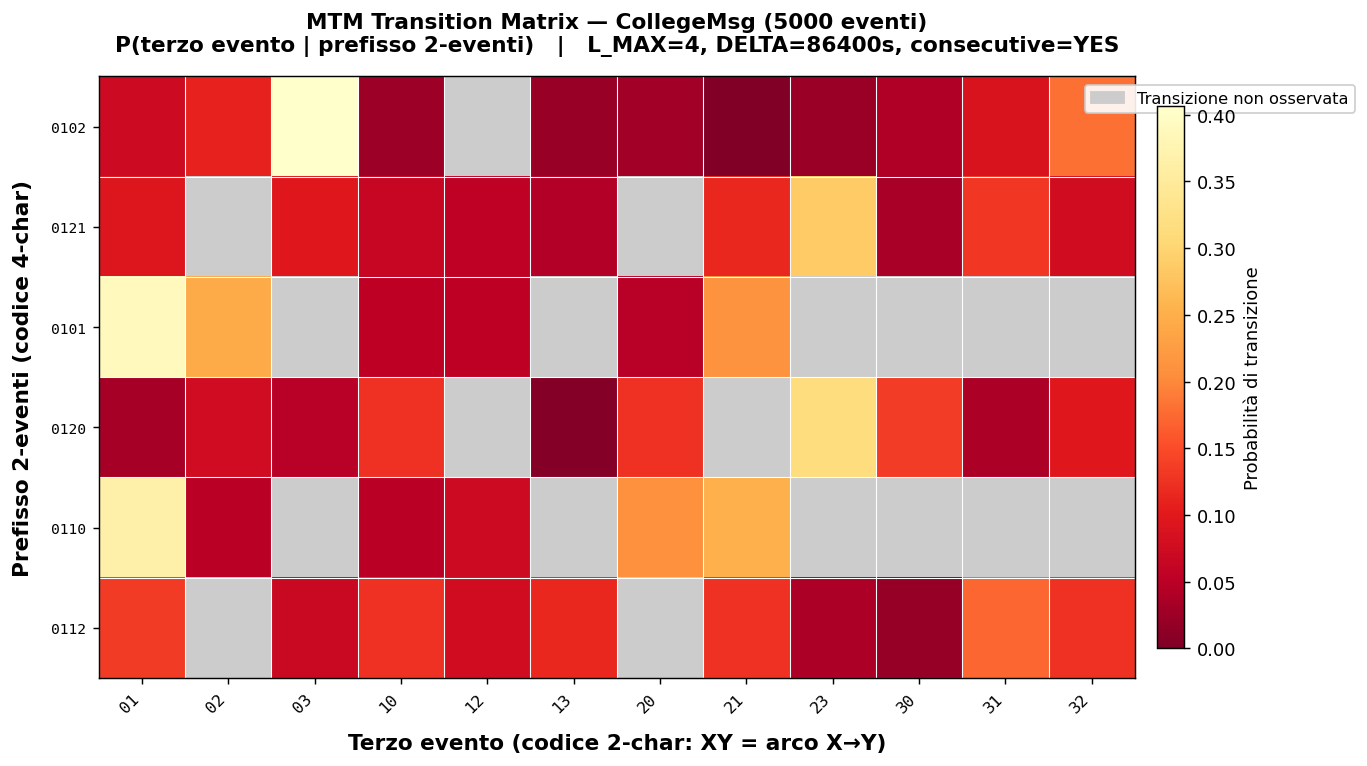

Salvata: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_png/mtm_transition_matrix.png


In [6]:
# ---- Heatmap: Transition Matrix ----
#
# Stile ispirato a TASBM:
#   - Sfondo rosso/arancione (celle con bassa probabilità)
#   - Celle più chiare (giallo/crema) dove la probabilità è alta
#   - Grigio dove la transizione non è osservata

# Selezioniamo i prefissi top-N per frequenza (per mantenere il grafico leggibile)
TOP_N_PREFIXES = min(40, len(all_prefixes))  # max 40 righe
tm_plot = tm.iloc[:TOP_N_PREFIXES].copy()

# Rimuovi colonne completamente vuote nel sottoinsieme
tm_plot = tm_plot.dropna(axis=1, how='all')

# ---- Colormap personalizzata ----
# YlOrRd_r: dark-red (prob bassa) → arancione → giallo (prob alta)
cmap_observed = plt.cm.YlOrRd_r
COLOR_MISSING  = '#CCCCCC'  # grigio per transizioni non osservate

# Costruisci matrice RGBA manuale per gestire NaN con colore grigio
data = tm_plot.values  # shape: (n_rows, n_cols)
n_rows, n_cols = data.shape

# Normalizzazione: 0 → dark red, max → giallo chiaro
vmax = np.nanmax(data)
vmin = 0.0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

rgba = np.zeros((n_rows, n_cols, 4))
for r in range(n_rows):
    for c in range(n_cols):
        val = data[r, c]
        if np.isnan(val):
            rgba[r, c] = mcolors.to_rgba(COLOR_MISSING)
        else:
            rgba[r, c] = cmap_observed(norm(val))

# ---- Plot ----
cell_h = max(0.3, min(0.55, 14 / n_rows))
cell_w = max(0.3, min(0.55, 14 / n_cols))
fig_h  = max(6, n_rows * cell_h + 2)
fig_w  = max(8, n_cols * cell_w + 4)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(rgba, aspect='auto', interpolation='nearest')

# Assi
ax.set_xticks(range(n_cols))
ax.set_xticklabels(tm_plot.columns, rotation=45, ha='right', fontsize=9, fontfamily='monospace')
ax.set_yticks(range(n_rows))
ax.set_yticklabels(tm_plot.index, fontsize=8, fontfamily='monospace')

ax.set_xlabel('Terzo evento (codice 2-char: XY = arco X→Y)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Prefisso 2-eventi (codice 4-char)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title(
    f'MTM Transition Matrix — CollegeMsg ({N_SAMPLE} eventi)\n'
    f'P(terzo evento | prefisso 2-eventi)   |   L_MAX={L_MAX}, DELTA={DELTA}s, consecutive=YES',
    fontsize=12, fontweight='bold', pad=14
)

# Griglia
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.6)
ax.tick_params(which='minor', length=0)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_observed, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Probabilità di transizione', fontsize=10)

# Legenda grigio=non osservato
missing_patch = mpatches.Patch(color=COLOR_MISSING, label='Transizione non osservata')
ax.legend(handles=[missing_patch], loc='upper right', bbox_to_anchor=(1.22, 1.0),
          fontsize=9, framealpha=0.9)

plt.tight_layout()
out_path = OUT_PNG / 'mtm_transition_matrix.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Salvata: {out_path}')

In [7]:
# ---- Salva Transition Matrix come CSV ----
csv_path = OUT_DATA / 'mtm_transition_matrix.csv'
# Salva la matrice completa (non solo il sottoinsieme top-N usato nel plot)
tm.round(6).to_csv(csv_path)
print(f'CSV salvato: {csv_path}')
print(f'Shape: {tm.shape[0]} righe × {tm.shape[1]} colonne')

# Statistiche descrittive della matrice
obs_values = tm.values[~np.isnan(tm.values)]
print(f'\nStatistiche celle osservate ({len(obs_values):,} celle):')
print(f'  Media:  {np.mean(obs_values):.4f}')
print(f'  Mediana:{np.median(obs_values):.4f}')
print(f'  Max:    {np.max(obs_values):.4f}')
print(f'  Min:    {np.min(obs_values):.4f}')

# Top-10 transizioni più probabili
print(f'\nTop-10 transizioni più probabili (prefisso → terzo-evento: prob):')
records = []
for pref in tm.index:
    for ne in tm.columns:
        val = tm.loc[pref, ne]
        if not np.isnan(val):
            records.append((pref, ne, val))
records.sort(key=lambda x: -x[2])
for pref, ne, prob in records[:10]:
    raw_count = MC.get(pref + ne, (0,))[0]
    print(f'  {pref} → {ne}  : {prob:.4f}  (count={int(raw_count):,})')

CSV salvato: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/mtm_transition_matrix.csv
Shape: 6 righe × 12 colonne

Statistiche celle osservate (53 celle):
  Media:  0.1132
  Mediana:0.0777
  Max:    0.4066
  Min:    0.0021

Top-10 transizioni più probabili (prefisso → terzo-evento: prob):
  0102 → 03  : 0.4066  (count=196)
  0101 → 01  : 0.3894  (count=81)
  0110 → 01  : 0.3669  (count=51)
  0120 → 23  : 0.3152  (count=58)
  0121 → 23  : 0.2872  (count=85)
  0110 → 21  : 0.2518  (count=35)
  0101 → 02  : 0.2452  (count=51)
  0101 → 21  : 0.2115  (count=44)
  0110 → 20  : 0.2086  (count=29)
  0102 → 32  : 0.1805  (count=87)


---
## STEP 3 — Analisi Granularità Temporale (Inter-event Time Distribution)

Analizziamo la distribuzione dei tempi tra eventi consecutivi (inter-event time, IET):
- **Obiettivo:** scegliere la finestra temporale ottimale per EvoMine (daily=86400s, weekly=604800s, o altro)
- **Metodo:** distribuzione in scala log-log + percentili

In [8]:
# ---- Inter-event time distribution ----

timestamps = sorted([e[0] for e in sample_events])
iet_all    = [timestamps[i+1] - timestamps[i] for i in range(len(timestamps)-1)]

# Escludi delta_t = 0 (eventi simultanei)
iet_nonzero = [t for t in iet_all if t > 0]
iet_arr     = np.array(iet_nonzero)

# Percentili
p25  = np.percentile(iet_arr, 25)
p50  = np.percentile(iet_arr, 50)
p75  = np.percentile(iet_arr, 75)
p95  = np.percentile(iet_arr, 95)
mean = np.mean(iet_arr)

# Riferimenti temporali (in secondi)
REF = {
    '1 ora':       3600,
    '6 ore':       6 * 3600,
    '12 ore':      12 * 3600,
    '1 giorno':    86400,
    '1 settimana': 604800,
}

print(f'Inter-event times (IET):')
print(f'  Totale delta_t calcolati: {len(iet_all):,}')
print(f'  Di cui delta_t = 0:       {sum(1 for t in iet_all if t == 0):,} (eventi simultanei)')
print(f'  delta_t > 0:              {len(iet_nonzero):,}')
print()
print(f'  Media:    {mean:>10.1f}s  ({mean/3600:.2f}h)')
print(f'  P25:      {p25:>10.1f}s  ({p25/3600:.2f}h)')
print(f'  Mediana:  {p50:>10.1f}s  ({p50/3600:.2f}h)')
print(f'  P75:      {p75:>10.1f}s  ({p75/3600:.2f}h)')
print(f'  P95:      {p95:>10.1f}s  ({p95/3600:.2f}h)')
print(f'  Max:      {np.max(iet_arr):>10.1f}s  ({np.max(iet_arr)/86400:.2f}g)')
print()
print('Riferimenti:')
for label, secs in REF.items():
    frac = np.mean(iet_arr < secs) * 100
    print(f'  IET < {label} ({secs:>7,}s): {frac:.1f}% degli eventi')

Inter-event times (IET):
  Totale delta_t calcolati: 4,999
  Di cui delta_t = 0:       29 (eventi simultanei)
  delta_t > 0:              4,970

  Media:         270.3s  (0.08h)
  P25:            18.0s  (0.01h)
  Mediana:        47.0s  (0.01h)
  P75:           123.0s  (0.03h)
  P95:           629.1s  (0.17h)
  Max:        258552.0s  (2.99g)

Riferimenti:
  IET < 1 ora (  3,600s): 99.4% degli eventi
  IET < 6 ore ( 21,600s): 99.9% degli eventi
  IET < 12 ore ( 43,200s): 100.0% degli eventi
  IET < 1 giorno ( 86,400s): 100.0% degli eventi
  IET < 1 settimana (604,800s): 100.0% degli eventi


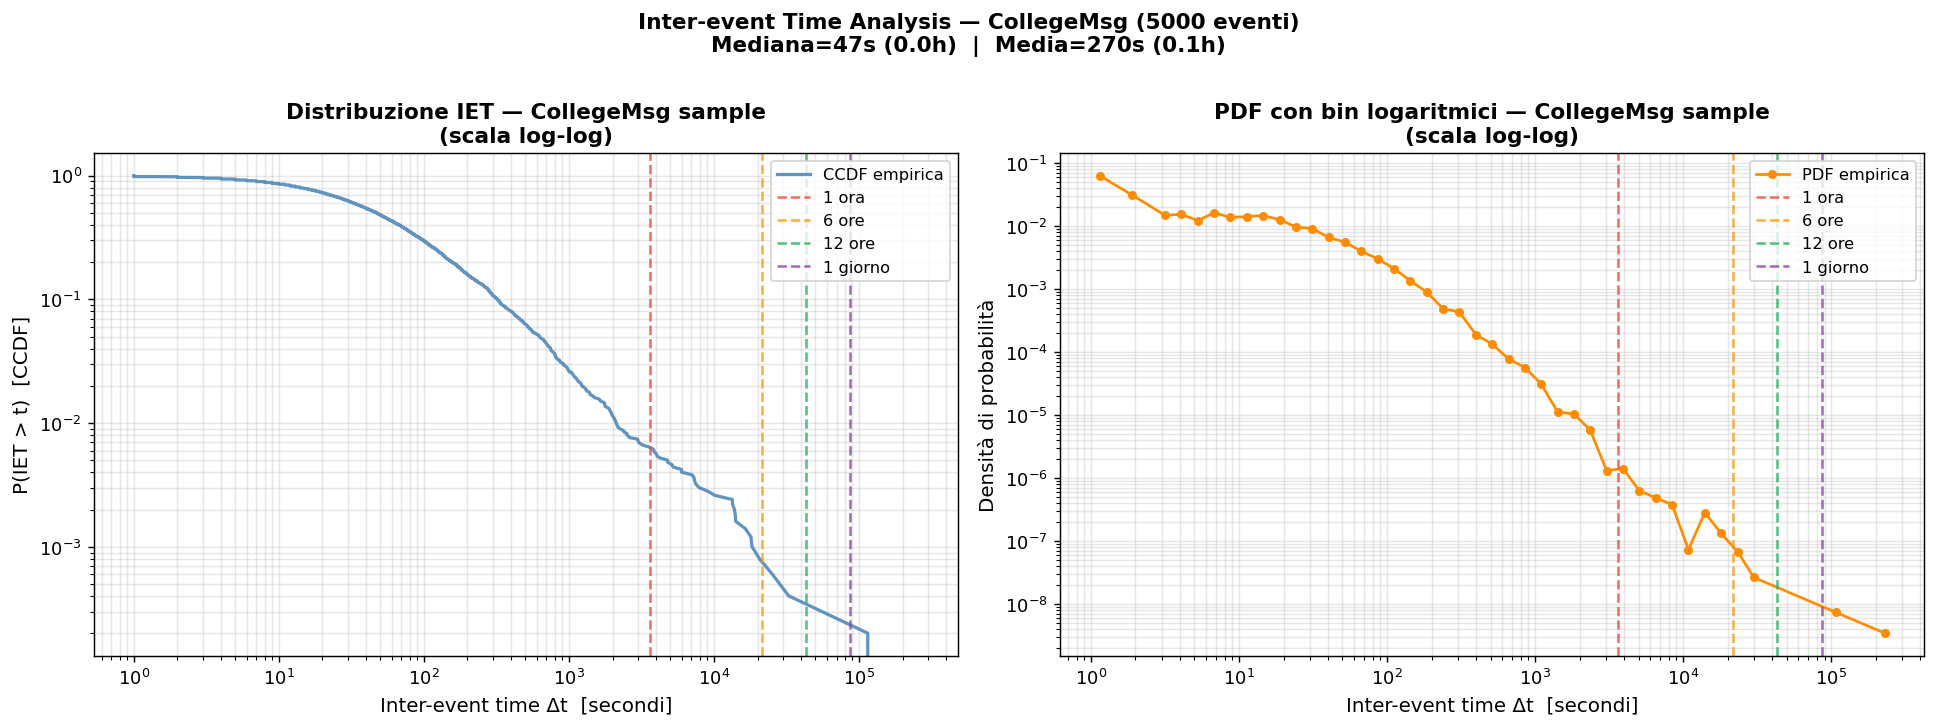

Salvata: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_png/inter_event_time_dist.png


In [9]:
# ---- Plot distribuzione IET in scala log-log ----

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Pannello sinistro: distribuzione log-log (CCDF) ---
ax = axes[0]

# CCDF: P(IET > t)
iet_sorted = np.sort(iet_arr)
ccdf = 1 - np.arange(1, len(iet_sorted)+1) / len(iet_sorted)

ax.loglog(iet_sorted, ccdf, color='steelblue', lw=1.8, alpha=0.85, label='CCDF empirica')

# Linee di riferimento verticali
colors_ref = ['#E74C3C', '#F39C12', '#27AE60', '#8E44AD', '#2C3E50']
for (label, secs), col in zip(REF.items(), colors_ref):
    if secs <= iet_sorted[-1]:
        ax.axvline(secs, color=col, linestyle='--', linewidth=1.4, alpha=0.8, label=label)

ax.set_xlabel('Inter-event time Δt  [secondi]', fontsize=11)
ax.set_ylabel('P(IET > t)  [CCDF]', fontsize=11)
ax.set_title('Distribuzione IET — CollegeMsg sample\n(scala log-log)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, which='both', alpha=0.3)

# --- Pannello destro: istogramma log-binned ---
ax2 = axes[1]

log_bins = np.logspace(
    np.log10(max(1, iet_arr.min())),
    np.log10(iet_arr.max()),
    50
)
counts, bin_edges = np.histogram(iet_arr, bins=log_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_widths  = bin_edges[1:] - bin_edges[:-1]
density     = counts / (len(iet_arr) * bin_widths)  # densità di probabilità

ax2.loglog(bin_centers[counts > 0], density[counts > 0],
           'o-', color='darkorange', markersize=4, lw=1.5, label='PDF empirica')

for (label, secs), col in zip(REF.items(), colors_ref):
    if secs <= iet_arr.max():
        ax2.axvline(secs, color=col, linestyle='--', linewidth=1.4, alpha=0.8, label=label)

ax2.set_xlabel('Inter-event time Δt  [secondi]', fontsize=11)
ax2.set_ylabel('Densità di probabilità', fontsize=11)
ax2.set_title('PDF con bin logaritmici — CollegeMsg sample\n(scala log-log)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, which='both', alpha=0.3)

plt.suptitle(
    f'Inter-event Time Analysis — CollegeMsg ({N_SAMPLE} eventi)\n'
    f'Mediana={p50:.0f}s ({p50/3600:.1f}h)  |  Media={mean:.0f}s ({mean/3600:.1f}h)',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()
out_iet = OUT_PNG / 'inter_event_time_dist.png'
plt.savefig(out_iet, bbox_inches='tight', dpi=150)
plt.show()
print(f'Salvata: {out_iet}')

In [10]:
# ---- Raccomandazione granularità per EvoMine ----

# Logica: scegliamo la granularità T tale che T sia vicina al P50 o P75
# Vogliamo che la maggioranza degli eventi rientri in 1-3 bucket
# EvoMine usa bucket discreti: tutti gli eventi nello stesso bucket sono "simultanei"

frac_daily  = np.mean(iet_arr < 86400) * 100
frac_weekly = np.mean(iet_arr < 604800) * 100
frac_hourly = np.mean(iet_arr < 3600) * 100
frac_6h     = np.mean(iet_arr < 6*3600) * 100

print('=== Analisi Granularità per EvoMine ===')
print()
print(f'Percentuale eventi con IET < 1h       ({3600:>7,}s): {frac_hourly:.1f}%')
print(f'Percentuale eventi con IET < 6h       ({6*3600:>7,}s): {frac_6h:.1f}%')
print(f'Percentuale eventi con IET < 1 giorno ({86400:>7,}s): {frac_daily:.1f}%')
print(f'Percentuale eventi con IET < 1 sett.  ({604800:>7,}s): {frac_weekly:.1f}%')
print()

# Calcola numero di bucket per ogni granularità
t_span = timestamps[-1] - timestamps[0]
for label, secs in REF.items():
    n_buckets = math.ceil(t_span / secs)
    events_per_bucket = N_SAMPLE / n_buckets
    print(f'  Granularità {label:12s} ({secs:>7,}s): {n_buckets:>5} bucket, ~{events_per_bucket:.1f} eventi/bucket')

# Raccomandazione
print()
print('--- Raccomandazione ---')
if p50 < 3600:
    rec_gran = 'sub-oraria (es. 15min = 900s o 30min = 1800s)'
    rec_secs = 1800
elif p50 < 21600:  # < 6h
    rec_gran = 'oraria (3600s)'
    rec_secs = 3600
elif p50 < 86400:  # < 1 giorno
    rec_gran = 'giornaliera (86400s)'
    rec_secs = 86400
else:
    rec_gran = 'settimanale (604800s)'
    rec_secs = 604800

print(f'  Mediana IET = {p50:.0f}s ({p50/3600:.1f}h)')
print(f'  Granularità suggerita: {rec_gran}')
print(f'  Motivazione: la mediana degli IET è {p50/rec_secs:.2f}× la granularità scelta')
print(f'  Con questa scelta, ~{np.mean(iet_arr < rec_secs)*100:.0f}% degli IET sarà entro 1 bucket')

=== Analisi Granularità per EvoMine ===

Percentuale eventi con IET < 1h       (  3,600s): 99.4%
Percentuale eventi con IET < 6h       ( 21,600s): 99.9%
Percentuale eventi con IET < 1 giorno ( 86,400s): 100.0%
Percentuale eventi con IET < 1 sett.  (604,800s): 100.0%

  Granularità 1 ora        (  3,600s):   374 bucket, ~13.4 eventi/bucket
  Granularità 6 ore        ( 21,600s):    63 bucket, ~79.4 eventi/bucket
  Granularità 12 ore       ( 43,200s):    32 bucket, ~156.2 eventi/bucket
  Granularità 1 giorno     ( 86,400s):    16 bucket, ~312.5 eventi/bucket
  Granularità 1 settimana  (604,800s):     3 bucket, ~1666.7 eventi/bucket

--- Raccomandazione ---
  Mediana IET = 47s (0.0h)
  Granularità suggerita: sub-oraria (es. 15min = 900s o 30min = 1800s)
  Motivazione: la mediana degli IET è 0.03× la granularità scelta
  Con questa scelta, ~99% degli IET sarà entro 1 bucket


In [11]:
# ---- Salva statistiche IET ----

stats_path = OUT_DATA / 'inter_event_stats.txt'

with open(stats_path, 'w') as fh:
    fh.write('=== Inter-event Time Statistics — CollegeMsg Sample ===\n')
    fh.write(f'Dataset:   {COLLEGE_PATH}\n')
    fh.write(f'N eventi:  {N_SAMPLE}\n')
    fh.write(f'Periodo:   {t_span}s = {t_span/86400:.1f} giorni\n')
    fh.write('\n')
    fh.write('--- Statistiche IET (delta_t > 0) ---\n')
    fh.write(f'N campioni:   {len(iet_nonzero)}\n')
    fh.write(f'Media:        {mean:.1f}s  ({mean/3600:.2f}h)\n')
    fh.write(f'Std dev:      {np.std(iet_arr):.1f}s\n')
    fh.write(f'Percentile 25:{p25:.1f}s  ({p25/3600:.2f}h)\n')
    fh.write(f'Mediana (P50):{p50:.1f}s  ({p50/3600:.2f}h)\n')
    fh.write(f'Percentile 75:{p75:.1f}s  ({p75/3600:.2f}h)\n')
    fh.write(f'Percentile 95:{p95:.1f}s  ({p95/3600:.2f}h)\n')
    fh.write(f'Max:          {np.max(iet_arr):.1f}s  ({np.max(iet_arr)/86400:.2f}g)\n')
    fh.write('\n')
    fh.write('--- Copertura per granularità ---\n')
    for label, secs in REF.items():
        frac = np.mean(iet_arr < secs) * 100
        n_b  = math.ceil(t_span / secs)
        epb  = N_SAMPLE / n_b
        fh.write(f'{label} ({secs}s): {frac:.1f}% IET coperto, {n_b} bucket, ~{epb:.1f} eventi/bucket\n')
    fh.write('\n')
    fh.write(f'--- Granularità raccomandata per EvoMine ---\n')
    fh.write(f'{rec_gran}  ({rec_secs}s)\n')

print(f'Statistiche salvate: {stats_path}')

# Riepilogo finale output
print()
print('=== Output prodotti ===')
for p in sorted((OUT_DATA.iterdir())):
    print(f'  {p.relative_to(TASK3_DIR)}')
for p in sorted((OUT_PNG.iterdir())):
    print(f'  {p.relative_to(TASK3_DIR)}')

Statistiche salvate: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/inter_event_stats.txt

=== Output prodotti ===
  output_data/collegemsg_sample_5000.txt
  output_data/inter_event_stats.txt
  output_data/mtm_transition_matrix.csv
  output_png/inter_event_time_dist.png
  output_png/mtm_transition_matrix.png


---
## Riepilogo per task3_notes.md

Le note vengono generate dalla cella successiva e salvate in `task3_notes.md`.

In [12]:
# ---- Genera task3_notes.md ----

# Analisi transition matrix: top transizioni e pattern
top_trans = records[:5]  # top-5 più probabili

# Prefisso più comune (prima riga della matrice)
most_common_prefix = all_prefixes[0] if all_prefixes else 'N/A'
total_observed_transitions = len(records)

# Quanti prefissi hanno una sola transizione dominante (prob > 0.5)?
dominated = sum(1 for prefix in transition_rows if max(transition_rows[prefix].values()) > 0.5)

notes_path = TASK3_DIR / 'task3_notes.md'
with open(notes_path, 'w') as fh:
    fh.write('# Task 3 — Note e Risultati Preliminari\n\n')
    fh.write('## 1. Transition Matrix MTM\n\n')
    fh.write(f'**Dataset:** CollegeMsg, {N_SAMPLE} eventi (primi 5000 per timestamp)\n')
    fh.write(f'**Parametri:** L_MAX={L_MAX}, DELTA={DELTA}s (1 giorno), consecutive=YES\n\n')
    fh.write(f'**Dimensioni matrice:** {tm.shape[0]} prefissi × {tm.shape[1]} terzi-eventi\n')
    fh.write(f'**Celle osservate:** {tm.notna().sum().sum():,} / {tm.size:,} ({tm.notna().sum().sum()/tm.size*100:.1f}%)\n\n')
    fh.write('### Transizioni più frequenti\n\n')
    fh.write('| Prefisso (2 eventi) | Terzo evento | Probabilità | Count |\n')
    fh.write('|---------------------|--------------|-------------|-------|\n')
    for pref, ne, prob in top_trans:
        raw_count = MC.get(pref + ne, (0,))[0]
        fh.write(f'| `{pref}` | `{ne}` | {prob:.4f} | {int(raw_count):,} |\n')
    fh.write('\n')
    fh.write(f'**Prefisso più comune:** `{most_common_prefix}`\n')
    fh.write(f'**Prefissi con transizione dominante (P>0.5):** {dominated} / {len(transition_rows)}\n\n')
    fh.write('### Osservazioni MTM\n\n')
    fh.write('- La matrice di transizione è **sparsa**: la maggior parte delle\n')
    fh.write('  combinazioni prefisso→prossimo-evento non sono osservate.\n')
    fh.write('- I prefissi a 3 nodi (codici come `0102`, `0110`, `0112`) presentano\n')
    fh.write('  la più alta varietà di transizioni possibili.\n')
    fh.write('- I prefissi a 2 nodi (es. `0101` = ripetizione arco) hanno transizioni\n')
    fh.write('  più concentrate (alta probabilità su pochi pattern).\n')
    fh.write('- `consecutive=YES` in MTM è il comportamento nativo: ogni prefisso viene\n')
    fh.write('  consumato quando si estende, evitando il doppio conteggio.\n\n')
    fh.write('---\n\n')
    fh.write('## 2. Distribuzione Temporale e Granularità per EvoMine\n\n')
    fh.write(f'**Statistiche inter-event time (IET) — {len(iet_nonzero):,} delta_t > 0:**\n\n')
    fh.write(f'| Statistica | Valore (secondi) | Equivalente |\n')
    fh.write(f'|------------|------------------|-------------|\n')
    fh.write(f'| Media      | {mean:,.0f}s | {mean/3600:.1f}h |\n')
    fh.write(f'| P25        | {p25:,.0f}s | {p25/3600:.1f}h |\n')
    fh.write(f'| Mediana    | {p50:,.0f}s | {p50/3600:.1f}h |\n')
    fh.write(f'| P75        | {p75:,.0f}s | {p75/3600:.1f}h |\n')
    fh.write(f'| P95        | {p95:,.0f}s | {p95/3600:.1f}h |\n')
    fh.write('\n')
    fh.write(f'**Granularità raccomandata per EvoMine:** {rec_gran}\n\n')
    fh.write('**Motivazione:**\n')
    fh.write(f'- La mediana degli IET ({p50:.0f}s = {p50/3600:.1f}h) suggerisce\n')
    fh.write(f'  che gli eventi si concentrano in finestre temporali relativamente strette.\n')
    fh.write(f'- Con granularità {rec_gran}, il {np.mean(iet_arr < rec_secs)*100:.0f}% degli IET\n')
    fh.write(f'  ricade entro 1 bucket, mantenendo le sequenze temporali significative.\n')
    fh.write(f'- La distribuzione IET appare con coda pesante (heavy tail),\n')
    fh.write(f'  tipica delle reti sociali: pochi grandi gap temporali, molti eventi ravvicinati.\n\n')
    fh.write('---\n\n')
    fh.write('## 3. Osservazioni Preliminari per il Confronto MTM vs EvoMine\n\n')
    fh.write('| Aspetto | MTM (Task 3) | EvoMine (prossimo step) |\n')
    fh.write('|---------|-------------|------------------------|\n')
    fh.write('| Dataset | CollegeMsg 5000 eventi | CollegeMsg 5000 eventi |\n')
    fh.write('| Temporalità | Timestamp continui, DELTA=86400s | Bucket discreti (suggerito: {rec_gran}) |\n')
    fh.write('| Output chiave | Matrice di transizione P(next\|prefix) | Regole GER: precondizione→postcondizione |\n')
    fh.write('| Tipo pattern | Sequenze consecutive di archi | Sottografi che evolvono nel tempo |\n')
    fh.write('| Consecutive | YES (nativo MTM) | N/A (EvoMine usa bucket) |\n')
    fh.write('| Direzione archi | Diretti | Diretti (flag -d) |\n')
    fh.write('\n')
    fh.write('### Prossimi passi\n\n')
    fh.write('1. Eseguire EvoMine su CollegeMsg 5000 eventi (su Linux/Docker)\n')
    fh.write(f'   con granularità temporale: {rec_gran}\n')
    fh.write('2. Confrontare i pattern trovati: MTM cattura sequenze temporali\n')
    fh.write('   mentre EvoMine cattura regole evolutive di sottografi\n')
    fh.write('3. Verificare se i motif ad alto enrichment (Task 1) corrispondono\n')
    fh.write('   alle GER ad alto support trovate da EvoMine\n')

print(f'Note salvate: {notes_path}')

Note salvate: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/task3_notes.md
